In [6]:
import pandas as pd

train_table = pd.read_csv("train.csv")
test_table = pd.read_csv("test.csv")

train_table.head(10)

,client_id,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,CC_0000F52C3717,50000,2,1,2,26,1,2,0,0,...,39475,40187,40992,2200,1962,1562,1500,1474,2300,0
1,CC_0008C4E44BB9,150000,2,1,2,26,-1,-1,-1,0,...,18400,1527,1527,0,18600,0,1527,0,0,0
2,CC_000B4B1BEDF6,450000,2,2,1,38,-2,-2,-2,-2,...,17255,17515,0,15008,1200,5255,4566,0,3648,0
3,CC_000D492CE7AD,230000,2,2,2,30,0,0,0,0,...,108826,100862,92481,6000,6000,4000,4000,3500,4000,0
4,CC_000DCFA992C4,160000,2,2,2,34,-1,-1,-1,-1,...,13780,12297,12752,24000,8000,13780,12300,12752,6000,0
5,CC_001122E39690,140000,2,2,2,32,-1,0,0,0,...,7453,38415,31685,1231,1262,1000,38415,4000,4000,0
6,CC_00117B7E053B,150000,2,3,2,28,0,0,0,0,...,100829,101913,96704,4000,4032,3410,4000,3665,3050,0
7,CC_00135124F0C3,150000,2,1,2,34,-2,-1,2,0,...,398,0,0,13206,0,0,0,0,0,0
8,CC_0016CFCF14C4,220000,2,1,1,37,0,0,0,0,...,162348,164162,168013,6000,7300,7500,6000,6500,7000,0
9,CC_001740B14C72,60000,2,2,2,21,0,0,0,0,...,25475,26010,26183,1859,1410,910,939,1000,1000,0


In [ ]:
#Check duplicate
# Check N/A
# Visualise variable
# Check outliers
# Categorise data (numerical and categorical)
# Multivariate analysis
train_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  24000 non-null  object
 1   LIMIT_BAL  24000 non-null  int64 
 2   SEX        24000 non-null  int64 
 3   EDUCATION  24000 non-null  int64 
 4   MARRIAGE   24000 non-null  int64 
 5   AGE        24000 non-null  int64 
 6   PAY_0      24000 non-null  int64 
 7   PAY_2      24000 non-null  int64 
 8   PAY_3      24000 non-null  int64 
 9   PAY_4      24000 non-null  int64 
 10  PAY_5      24000 non-null  int64 
 11  PAY_6      24000 non-null  int64 
 12  BILL_AMT1  24000 non-null  int64 
 13  BILL_AMT2  24000 non-null  int64 
 14  BILL_AMT3  24000 non-null  int64 
 15  BILL_AMT4  24000 non-null  int64 
 16  BILL_AMT5  24000 non-null  int64 
 17  BILL_AMT6  24000 non-null  int64 
 18  PAY_AMT1   24000 non-null  int64 
 19  PAY_AMT2   24000 non-null  int64 
 20  PAY_AMT3   24000 non-null  i

In [ ]:
train_table.isnull().sum()

np.int64(0)

In [11]:
train_table["EDUCATION"].value_counts()

EDUCATION
2    11151
1     8551
3     3911
5      237
4       97
6       43
0       10
Name: count, dtype: int64

In [12]:
train_table["MARRIAGE"].value_counts()

MARRIAGE
2    12685
1    11019
3      254
0       42
Name: count, dtype: int64

In [13]:
train_table['SEX'].value_counts()

SEX
2    14443
1     9557
Name: count, dtype: int64

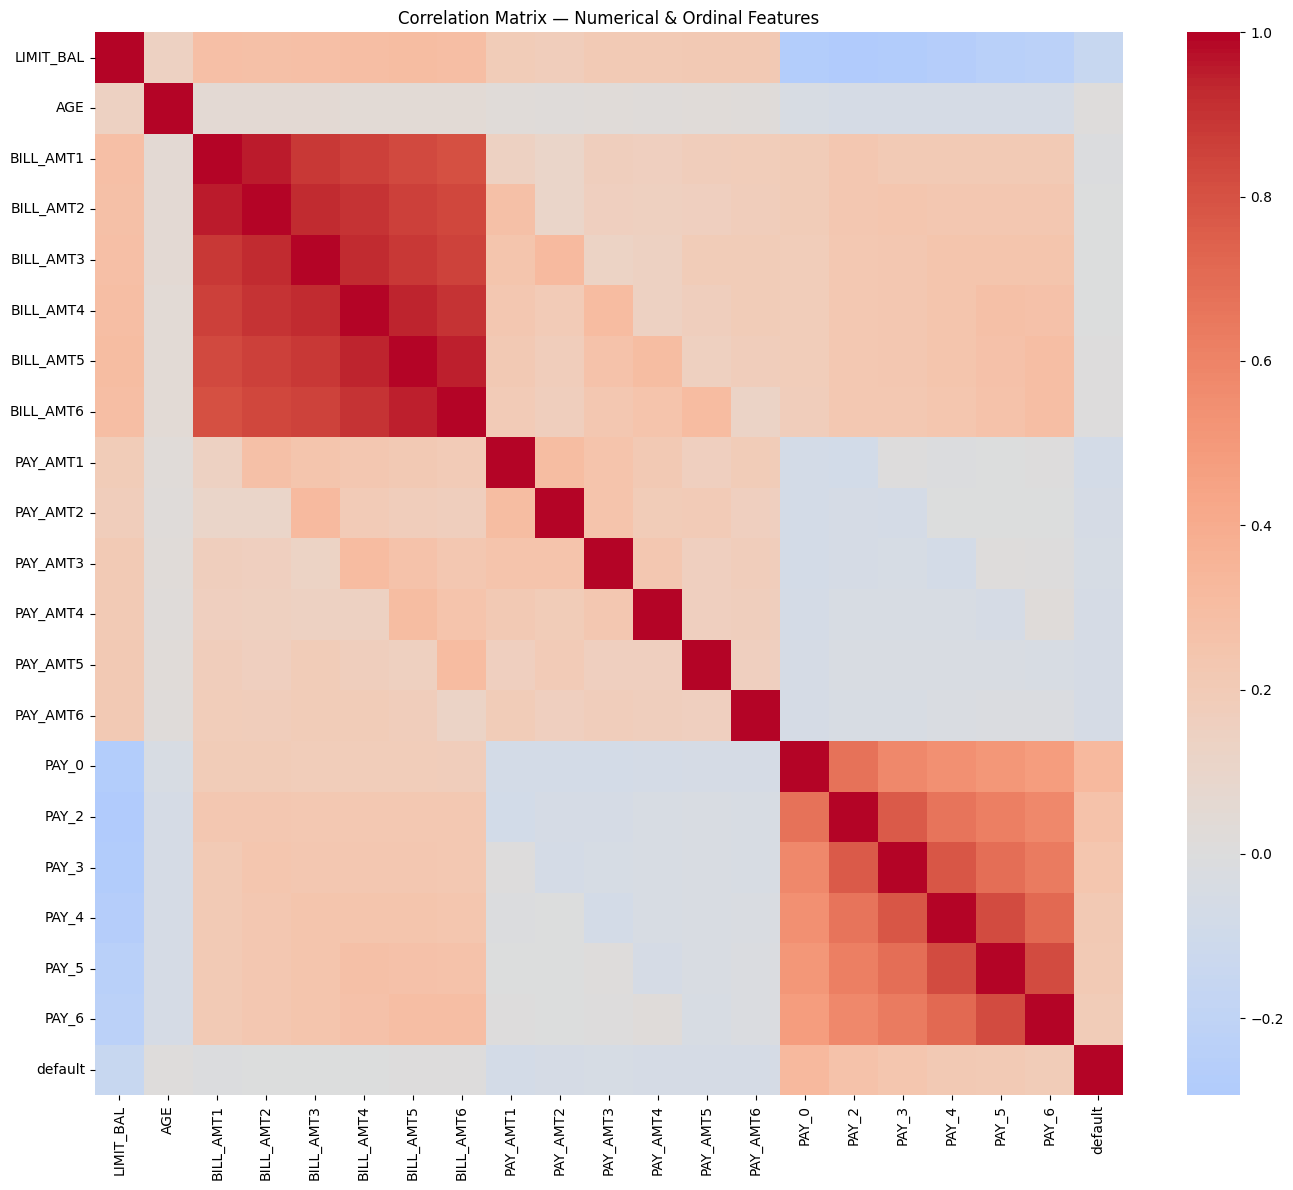

Correlation with default (sorted):
PAY_0        0.325247
PAY_2        0.263660
PAY_3        0.239857
PAY_4        0.218190
PAY_5        0.208061
PAY_6        0.189830
AGE          0.012337
BILL_AMT6    0.003479
BILL_AMT5    0.001425
BILL_AMT4   -0.001944
BILL_AMT2   -0.005325
BILL_AMT3   -0.005344
BILL_AMT1   -0.010970
PAY_AMT3    -0.049802
PAY_AMT6    -0.053357
PAY_AMT2    -0.054406
PAY_AMT5    -0.055861
PAY_AMT4    -0.058017
PAY_AMT1    -0.070868
LIMIT_BAL   -0.150638
Name: default, dtype: float64

Highly correlated feature pairs (|r| > 0.8):
BILL_AMT1  BILL_AMT2    0.950214
BILL_AMT5  BILL_AMT6    0.947459
BILL_AMT4  BILL_AMT5    0.940923
BILL_AMT2  BILL_AMT3    0.926124
BILL_AMT3  BILL_AMT4    0.920475
BILL_AMT4  BILL_AMT6    0.901859
BILL_AMT2  BILL_AMT4    0.893971
BILL_AMT1  BILL_AMT3    0.888402
BILL_AMT3  BILL_AMT5    0.882500
BILL_AMT2  BILL_AMT5    0.862650
BILL_AMT1  BILL_AMT4    0.861326
BILL_AMT3  BILL_AMT6    0.852067
BILL_AMT2  BILL_AMT6    0.834050
BILL_AMT1  BILL_AMT5

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ordinal_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
numerical_cols = ['LIMIT_BAL', 'AGE',
                   'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                   'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


corr = train_table[numerical_cols + ordinal_cols + ['default']].corr()


plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix — Numerical & Ordinal Features')
plt.tight_layout()
plt.show()

print("Correlation with default (sorted):")
print(corr['default'].drop('default').sort_values(ascending=False))

# Flag multicollinear pairs (|corr| > 0.8)
c = corr.drop(columns='default').drop(index='default')
mask = np.triu(np.ones(c.shape), k=1).astype(bool)
high_pairs = c.where(mask).stack()
high_pairs = high_pairs[high_pairs.abs() > 0.8].sort_values(ascending=False)
print("\nHighly correlated feature pairs (|r| > 0.8):")
print(high_pairs)


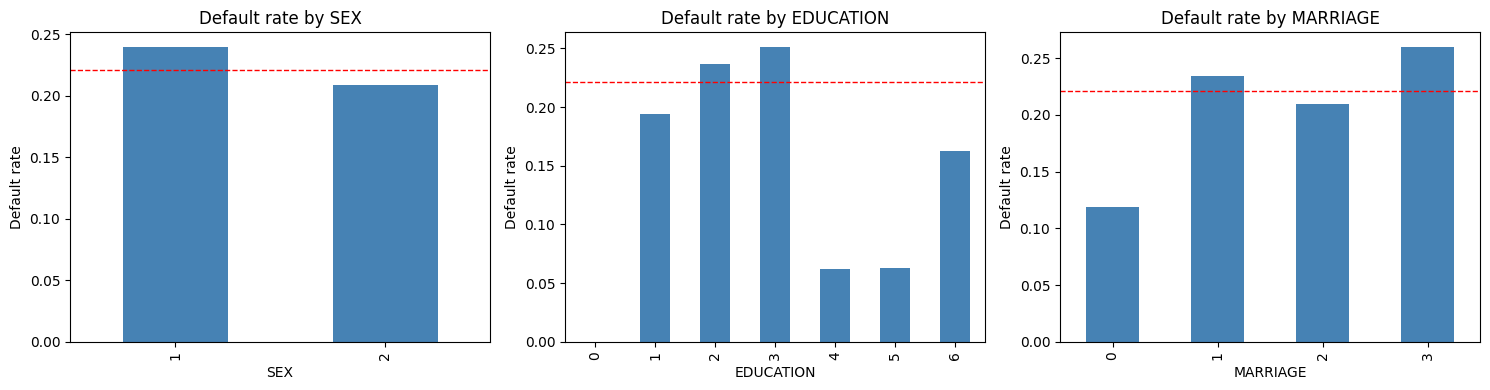


Default rate by SEX:
         mean  count
SEX                 
1    0.239615   9557
2    0.209029  14443

Default rate by EDUCATION:
               mean  count
EDUCATION                 
0          0.000000     10
1          0.194129   8551
2          0.236660  11151
3          0.251087   3911
4          0.061856     97
5          0.063291    237
6          0.162791     43

Default rate by MARRIAGE:
              mean  count
MARRIAGE                 
0         0.119048     42
1         0.233960  11019
2         0.209696  12685
3         0.259843    254


In [21]:
# ══════════════════════════════════════════════════════════════
# 2. CATEGORICAL FEATURES vs TARGET (default rate by group)
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
for ax, col in zip(axes, categorical_cols):
    rate = train_table.groupby(col)['default'].mean().sort_index()
    rate.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Default rate by {col}')
    ax.set_ylabel('Default rate')
    ax.axhline(train_table['default'].mean(), color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

for col in categorical_cols:
    print(f"\nDefault rate by {col}:")
    print(train_table.groupby(col)['default'].agg(['mean', 'count']))

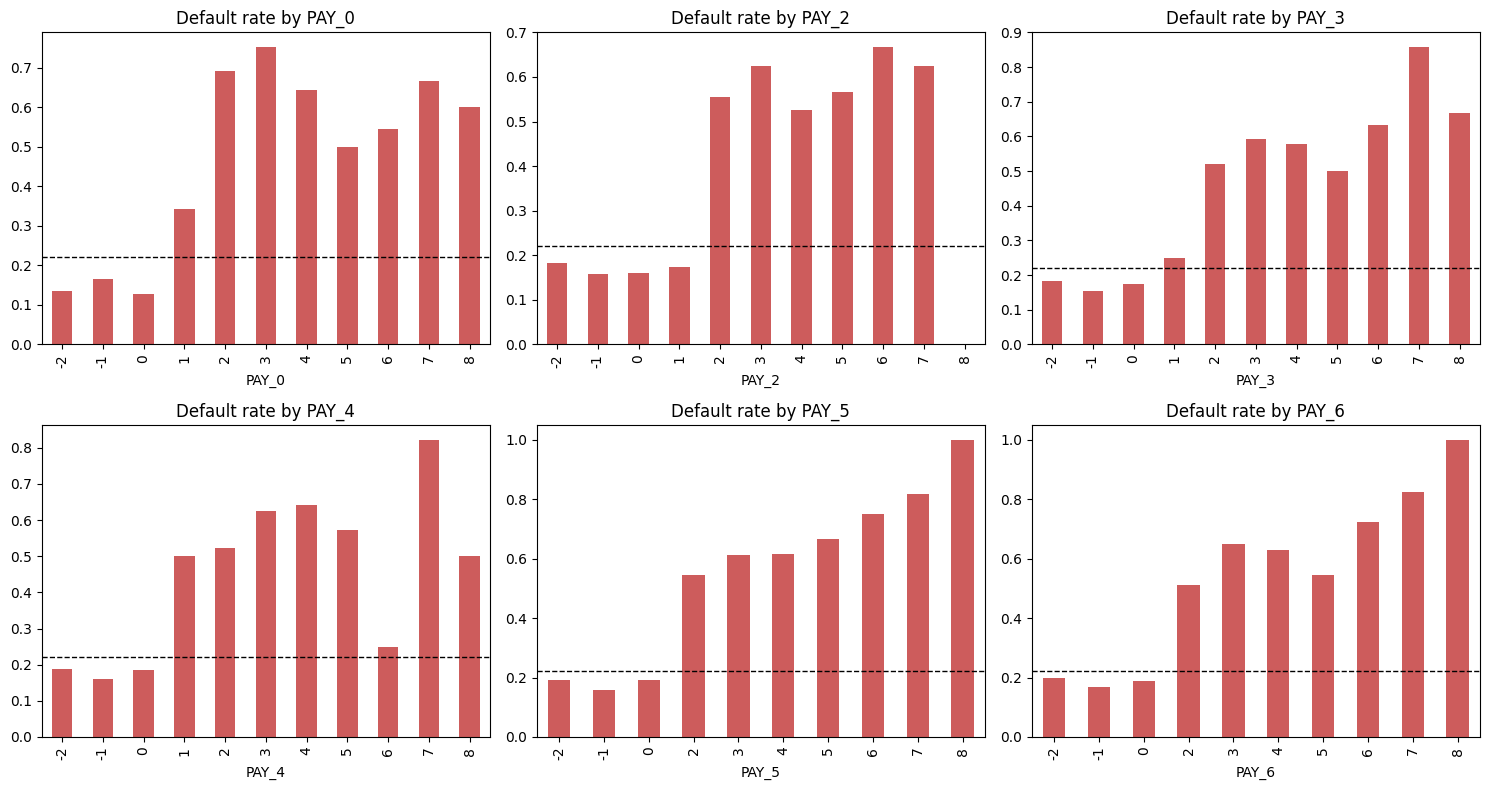

In [24]:
# ══════════════════════════════════════════════════════════════
# 3. ORDINAL PAY_* FEATURES vs TARGET
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), ordinal_cols):
    rate = train_table.groupby(col)['default'].mean().sort_index()
    rate.plot(kind='bar', ax=ax, color='indianred')
    ax.set_title(f'Default rate by {col}')
    ax.axhline(train_table['default'].mean(), color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


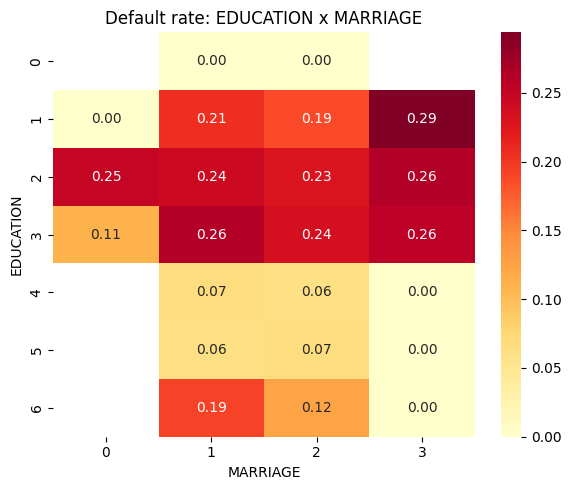

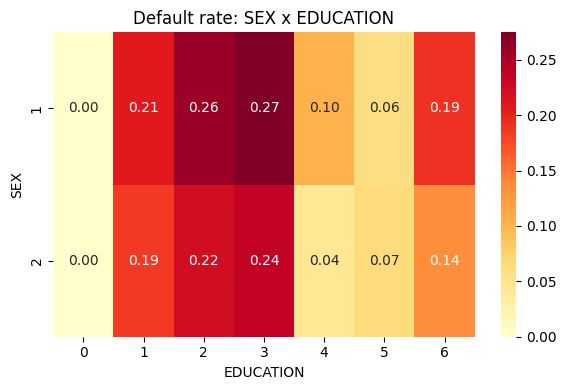

In [26]:
# ══════════════════════════════════════════════════════════════
# 4. TWO-WAY INTERACTIONS (categorical x categorical)
# ══════════════════════════════════════════════════════════════
pivot = train_table.pivot_table(index='EDUCATION', columns='MARRIAGE',
                            values='default', aggfunc='mean')
plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Default rate: EDUCATION x MARRIAGE')
plt.tight_layout()
plt.show()

pivot2 = train_table.pivot_table(index='SEX', columns='EDUCATION',
                             values='default', aggfunc='mean')
plt.figure(figsize=(6, 4))
sns.heatmap(pivot2, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Default rate: SEX x EDUCATION')
plt.tight_layout()
plt.show()

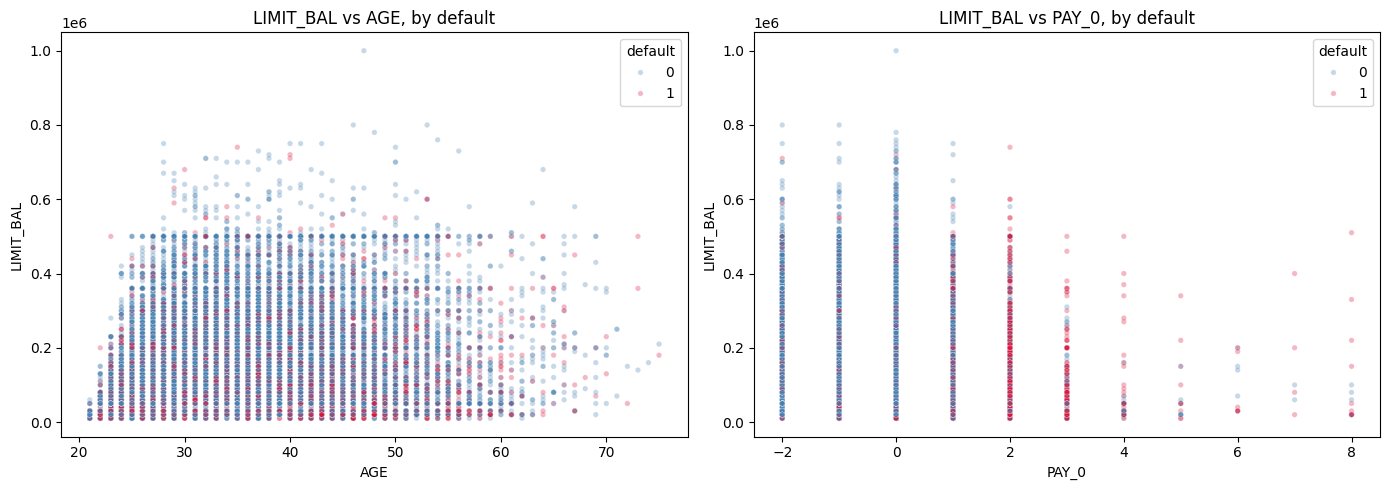

In [28]:
# ══════════════════════════════════════════════════════════════
# 5. NUMERICAL x NUMERICAL scatter, colored by target
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=train_table, x='AGE', y='LIMIT_BAL', hue='default',
                 alpha=0.3, s=15, ax=axes[0], palette=['steelblue', 'crimson'])
axes[0].set_title('LIMIT_BAL vs AGE, by default')

sns.scatterplot(data=train_table, x='PAY_0', y='LIMIT_BAL', hue='default',
                 alpha=0.3, s=15, ax=axes[1], palette=['steelblue', 'crimson'])
axes[1].set_title('LIMIT_BAL vs PAY_0, by default')
plt.tight_layout()
plt.show()

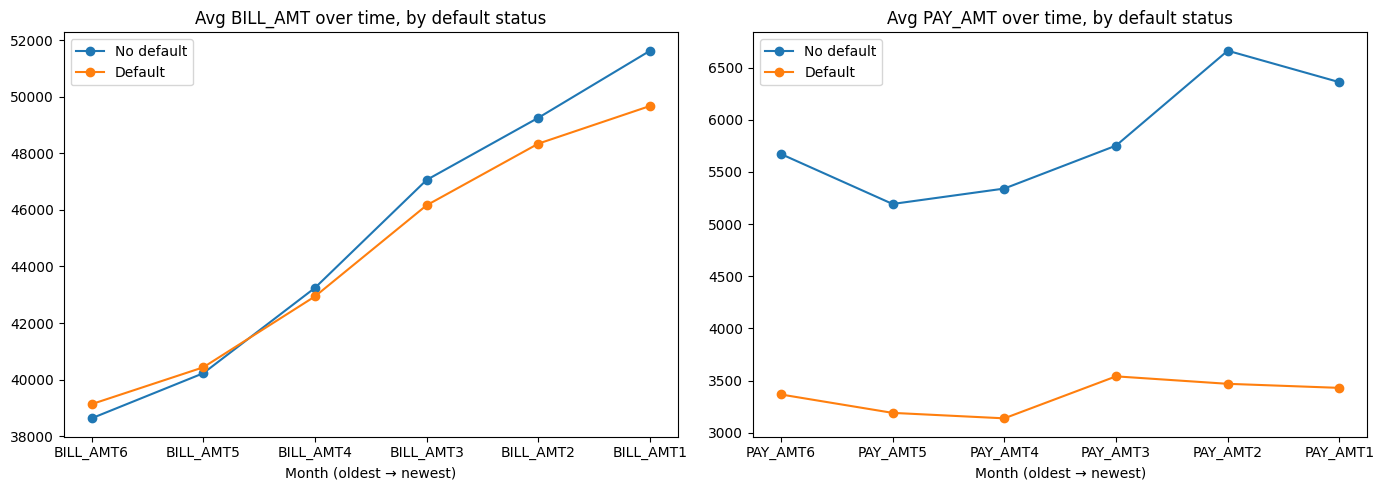

In [31]:
# ══════════════════════════════════════════════════════════════
# 6. BILL/PAYMENT TRENDS OVER TIME, split by default status
# ══════════════════════════════════════════════════════════════
bill_cols = ['BILL_AMT6', 'BILL_AMT5', 'BILL_AMT4', 'BILL_AMT3', 'BILL_AMT2', 'BILL_AMT1']  # chronological order
pay_cols  = ['PAY_AMT6', 'PAY_AMT5', 'PAY_AMT4', 'PAY_AMT3', 'PAY_AMT2', 'PAY_AMT1']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_table.groupby('default')[bill_cols].mean().T.plot(marker='o', ax=axes[0])
axes[0].set_title('Avg BILL_AMT over time, by default status')
axes[0].set_xlabel('Month (oldest → newest)')
axes[0].legend(['No default', 'Default'])

train_table.groupby('default')[pay_cols].mean().T.plot(marker='o', ax=axes[1])
axes[1].set_title('Avg PAY_AMT over time, by default status')
axes[1].set_xlabel('Month (oldest → newest)')
axes[1].legend(['No default', 'Default'])

plt.tight_layout()
plt.show()

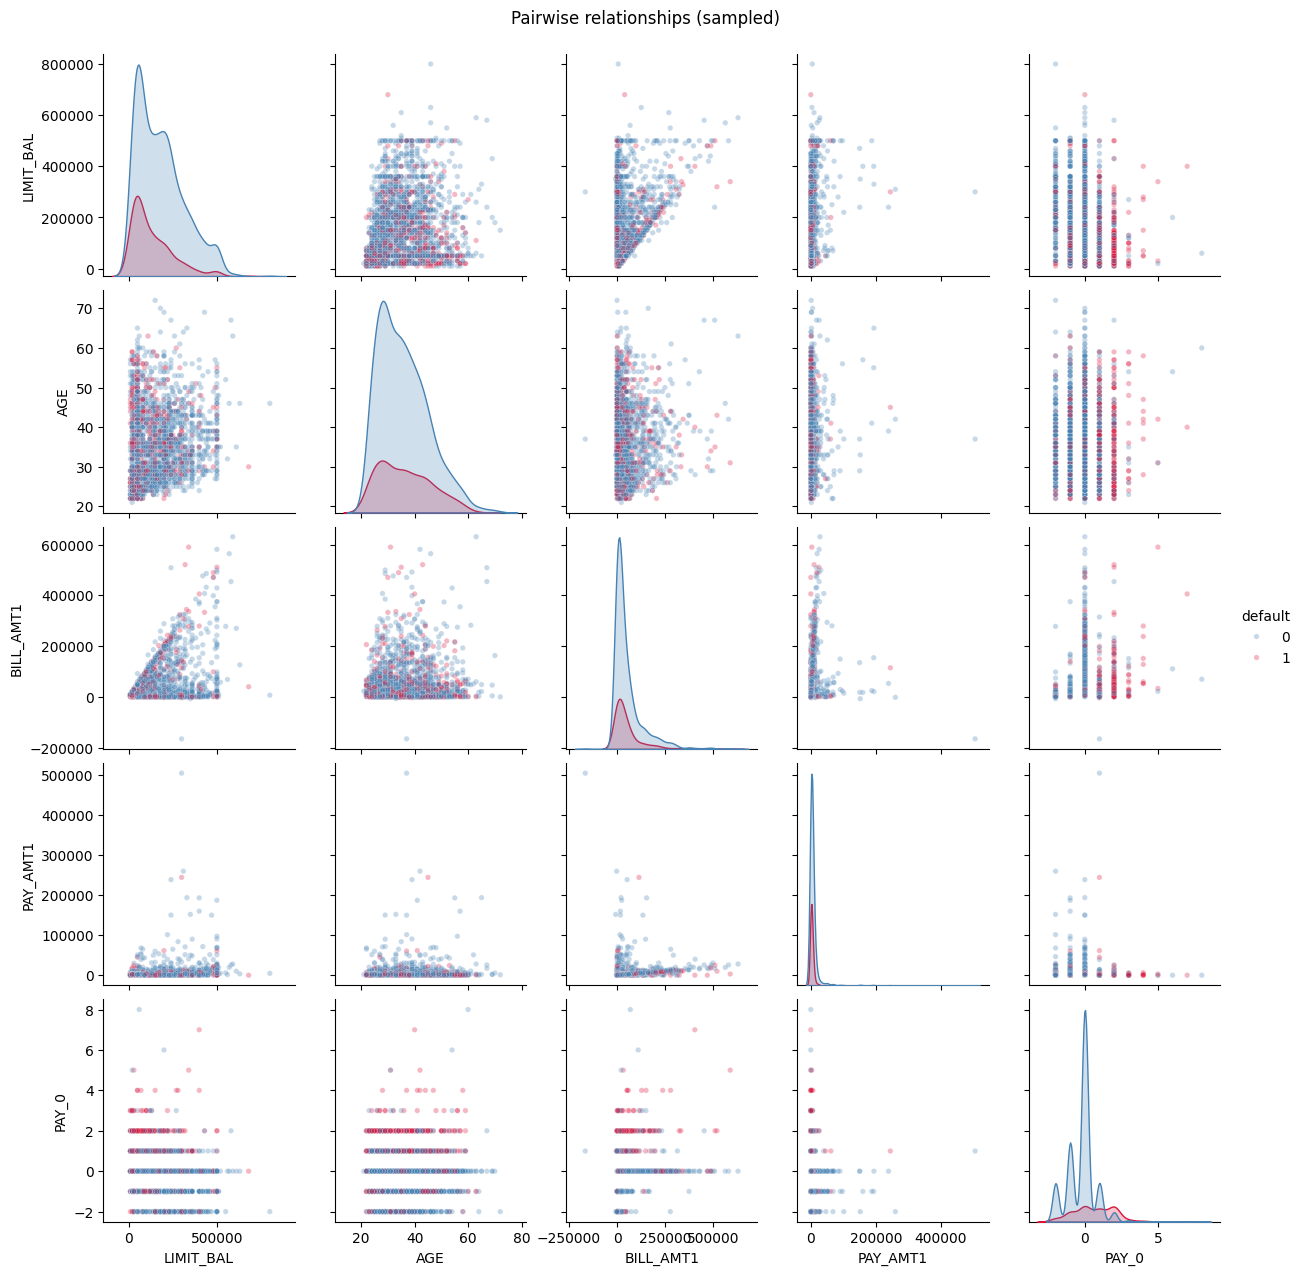

In [33]:
# ══════════════════════════════════════════════════════════════
# 7. PAIRPLOT on a reduced feature subset (expensive — use sample)
# ══════════════════════════════════════════════════════════════
subset_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'PAY_0', 'default']
sample = train_table[subset_cols].sample(2000, random_state=42)  # sample for speed
sns.pairplot(sample, hue='default', diag_kind='kde',
             plot_kws={'alpha': 0.3, 's': 15}, palette=['steelblue', 'crimson'])
plt.suptitle('Pairwise relationships (sampled)', y=1.02)
plt.show()